In [1]:
%pip install chromadb

   ---------------------------------------- 0.0/23.5 MB ? eta -:--:--
   - -------------------------------------- 0.8/23.5 MB 5.6 MB/s eta 0:00:05
   -- ------------------------------------- 1.3/23.5 MB 3.7 MB/s eta 0:00:06
   ---- ----------------------------------- 2.4/23.5 MB 4.1 MB/s eta 0:00:06
   ----- ---------------------------------- 3.1/23.5 MB 4.1 MB/s eta 0:00:05
   ------- -------------------------------- 4.2/23.5 MB 4.5 MB/s eta 0:00:05
   ---------- ----------------------------- 6.0/23.5 MB 5.1 MB/s eta 0:00:04
   ------------ --------------------------- 7.1/23.5 MB 5.3 MB/s eta 0:00:04
   --------------- ------------------------ 8.9/23.5 MB 5.6 MB/s eta 0:00:03
   ------------------ --------------------- 10.7/23.5 MB 6.0 MB/s eta 0:00:03
   -------------------- ------------------- 12.3/23.5 MB 6.3 MB/s eta 0:00:02
   ------------------------ --------------- 14.2/23.5 MB 6.5 MB/s eta 0:00:02
   -------------------------- ------------- 15.5/23.5 MB 6.4 MB/s eta 0:00:02
  

In [2]:
import chromadb
from sentence_transformers import SentenceTransformer

d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
client = chromadb.Client()

collection = client.create_collection("ai_water_docs")

print("Collection created:", collection.name)

Collection created: ai_water_docs


In [4]:
docs = [
    "AI can predict flood risks by analyzing satellite imagery and weather patterns.",
    "Machine learning models detect illegal deforestation in the Amazon rainforest.",
    "Neural networks classify water quality from sensor data in real time.",
    "AI-powered drones monitor coral reef health and detect bleaching events.",
    "Deep learning models predict air pollution levels in urban areas.",
    "Natural language processing helps scientists extract climate data from research papers.",
    "Reinforcement learning optimizes energy consumption in smart grids.",
    "Computer vision detects plastic waste in oceans using satellite images.",
    "AI forecasting models help farmers optimize irrigation to reduce water usage.",
    "Machine learning detects methane leaks from oil pipelines using infrared imagery.",
]

metadatas = [
    {"title": "Flood Prediction", "source": "scientific"},
    {"title": "Deforestation Detection", "source": "news"},
    {"title": "Water Quality", "source": "scientific"},
    {"title": "Coral Reef Monitoring", "source": "scientific"},
    {"title": "Air Pollution", "source": "scientific"},
    {"title": "Climate Data Extraction", "source": "research"},
    {"title": "Smart Grid Optimization", "source": "research"},
    {"title": "Ocean Plastic Detection", "source": "news"},
    {"title": "Irrigation Optimization", "source": "research"},
    {"title": "Methane Leak Detection", "source": "scientific"},
]

ids = [f"doc{i}" for i in range(len(docs))]

collection.add(
    documents=docs,
    metadatas=metadatas,
    ids=ids
)

print("Documents added:", collection.count())

C:\Users\hp\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:17<00:00, 4.82MiB/s]


Documents added: 10


In [5]:
query1 = "How does AI detect water pollution?"

results1 = collection.query(
    query_texts=[query1],
    n_results=3
)

print("Query:", query1)
print()
for i in range(3):
    print(f"Rank {i+1}: {results1['documents'][0][i]}")
    print(f"Metadata: {results1['metadatas'][0][i]}")
    print(f"Distance: {results1['distances'][0][i]:.4f}")
    print()

Query: How does AI detect water pollution?

Rank 1: Neural networks classify water quality from sensor data in real time.
Metadata: {'source': 'scientific', 'title': 'Water Quality'}
Distance: 0.7410

Rank 2: AI can predict flood risks by analyzing satellite imagery and weather patterns.
Metadata: {'source': 'scientific', 'title': 'Flood Prediction'}
Distance: 0.8715

Rank 3: AI forecasting models help farmers optimize irrigation to reduce water usage.
Metadata: {'source': 'research', 'title': 'Irrigation Optimization'}
Distance: 0.9797



In [6]:
query2 = "Which AI models help with climate and energy?"

results2 = collection.query(
    query_texts=[query2],
    n_results=3
)

print("Query:", query2)
print()
for i in range(3):
    print(f"Rank {i+1}: {results2['documents'][0][i]}")
    print(f"Metadata: {results2['metadatas'][0][i]}")
    print(f"Distance: {results2['distances'][0][i]:.4f}")
    print()

Query: Which AI models help with climate and energy?

Rank 1: AI forecasting models help farmers optimize irrigation to reduce water usage.
Metadata: {'source': 'research', 'title': 'Irrigation Optimization'}
Distance: 0.8703

Rank 2: AI can predict flood risks by analyzing satellite imagery and weather patterns.
Metadata: {'title': 'Flood Prediction', 'source': 'scientific'}
Distance: 0.9798

Rank 3: Natural language processing helps scientists extract climate data from research papers.
Metadata: {'title': 'Climate Data Extraction', 'source': 'research'}
Distance: 1.0644



In [7]:
query3 = "How does AI monitor oceans and forests?"

results3 = collection.query(
    query_texts=[query3],
    n_results=3
)

print("Query:", query3)
print()
for i in range(3):
    print(f"Rank {i+1}: {results3['documents'][0][i]}")
    print(f"Metadata: {results3['metadatas'][0][i]}")
    print(f"Distance: {results3['distances'][0][i]:.4f}")
    print()

Query: How does AI monitor oceans and forests?

Rank 1: AI-powered drones monitor coral reef health and detect bleaching events.
Metadata: {'title': 'Coral Reef Monitoring', 'source': 'scientific'}
Distance: 0.9430

Rank 2: AI can predict flood risks by analyzing satellite imagery and weather patterns.
Metadata: {'source': 'scientific', 'title': 'Flood Prediction'}
Distance: 0.9987

Rank 3: Machine learning models detect illegal deforestation in the Amazon rainforest.
Metadata: {'title': 'Deforestation Detection', 'source': 'news'}
Distance: 1.0208



In [8]:
results_filtered = collection.query(
    query_texts=["AI and environment"],
    n_results=3,
    where={"source": "scientific"}
)

print("Filtered to source=scientific only:")
print()
for i in range(3):
    print(f"Rank {i+1}: {results_filtered['documents'][0][i]}")
    print(f"Metadata: {results_filtered['metadatas'][0][i]}")
    print()

Filtered to source=scientific only:

Rank 1: AI can predict flood risks by analyzing satellite imagery and weather patterns.
Metadata: {'title': 'Flood Prediction', 'source': 'scientific'}

Rank 2: Neural networks classify water quality from sensor data in real time.
Metadata: {'title': 'Water Quality', 'source': 'scientific'}

Rank 3: AI-powered drones monitor coral reef health and detect bleaching events.
Metadata: {'source': 'scientific', 'title': 'Coral Reef Monitoring'}



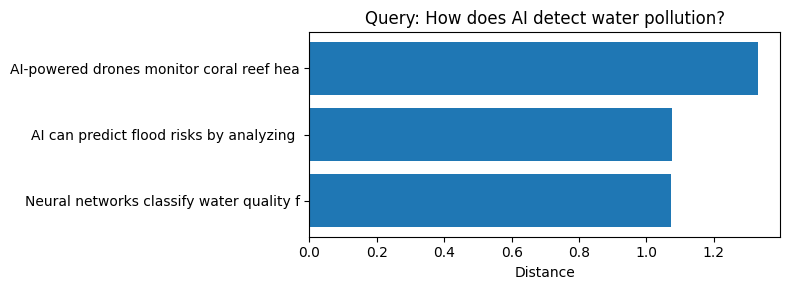

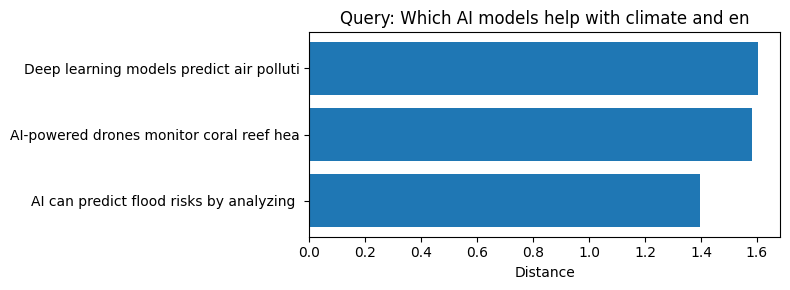

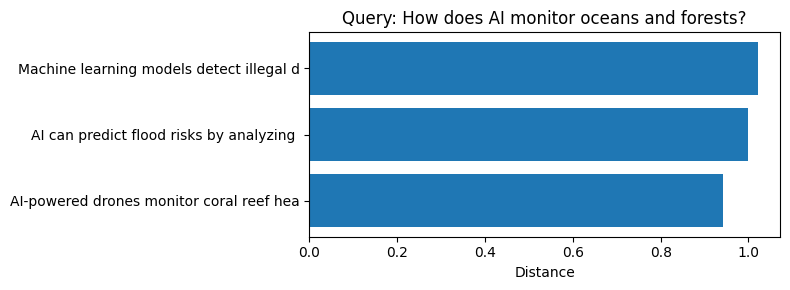

In [10]:
import matplotlib.pyplot as plt

queries = [query1, query2, query3]
all_results = [results1, results2, results3]

for q, res in zip(queries, all_results):
    docs_retrieved = [res['documents'][0][i][:40] for i in range(3)]
    distances = [res['distances'][0][i] for i in range(3)]
    
    plt.figure(figsize=(8, 3))
    plt.barh(docs_retrieved, distances)
    plt.xlabel("Distance")
    plt.title(f"Query: {q[:40]}")
    plt.tight_layout()
    plt.show()

In [11]:
%pip install langchain langchain-community

Note: you may need to restart the kernel to use updated packages.


In [12]:
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.chains import RetrievalQA
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

In [14]:
embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = Chroma.from_texts(
    texts=docs,
    embedding=embedding_model,
    metadatas=metadatas
)


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [19]:
generator = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",
    max_new_tokens=100
)

llm = HuggingFacePipeline(pipeline=generator)

In [20]:
from langchain.chains import RetrievalQA

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vectorstore.as_retriever(search_kwargs={"k": 3}),
)

question = "How does AI help with water pollution?"
answer = qa_chain.invoke({"query": question})

print("Question:", question)
print("Answer:", answer["result"])

Question: How does AI help with water pollution?
Answer: analyzing satellite imagery and weather patterns
